# Week 4 Analysis - What irregular activity occurred on r/place?

Identify the major buckets of irregular activity; meaning pixels not placed by regular human users. Your final analysis should consist of a neatly formatted analysis. For each bucket of activity, you should include:

1. Describe in human terms of what the activity is

2. Give several concrete examples of the activity as it happened in r/place. Visualizations should be used here.

3. Link to a python script that detects the described activity and give a short human description of your detection mechanism

In [1]:
import duckdb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib.animation import FFMpegWriter
import datetime

PARQUET_PATH = "../2022_place_canvas_history.parquet"

### Let's start with creating a small animation of pixel placements during a given timeframe.

In [50]:
def hex_to_rgb(h: str):
    h = h.lstrip("#")
    return tuple(int(h[i:i+2], 16)/255.0 for i in (0, 2, 4))

def local(xmin, ymin, x, y):
    return x - xmin, y - ymin

def createGif(xmin: int, xmax: int, ymin: int , ymax: int, 
              df: pd.DataFrame, bins: int = 100, 
              file: str = None, 
              fps: int = 10, dt: int = 50):
    
    if (not file):
        file = f"rplace_{xmin}_{xmax}_{ymin}_{ymax}.gif"
    width = xmax - xmin + 50
    height = ymax - ymin + 50

    canvas = np.ones((height, width, 3))

    time_bin = bins

    df["rgb"] = df["pixel_color"].apply(hex_to_rgb)

    df["frame"] = (df["timestamp_epoch"] // time_bin)

    groups = list(df.groupby("frame"))

    fig, ax = plt.subplots()
    img = ax.imshow(canvas)
    ax.axis("off")

    fig.subplots_adjust(left=0, right=1, bottom=0, top=1)
    ax.set_position([0, 0, 1, 1])

    def update(frame):
        _, chunk = groups[frame]

        if chunk.empty:
            return [img]

        for _, row in chunk.iterrows():
            x2 = row['x2'] if not pd.isna(row.get('x2', np.nan)) else row['x1']
            y2 = row['y2'] if not pd.isna(row.get('y2', np.nan)) else row['y1']

            x_start = min(row['x1'], x2)
            x_end = max(row['x1'], x2)

            y_start = min(row['y1'], y2)
            y_end = max(row['y1'], y2)

            x_start, y_start = local(xmin, ymin, x_start, y_start)
            x_end, y_end = local(xmin, ymin, x_end, y_end)

            xs = np.arange(x_start, x_end + 1)
            ys = np.arange(y_start, y_end + 1)

            xs = xs[(xs >= 0) & (xs < canvas.shape[1])]
            ys = ys[(ys >= 0) & (ys < canvas.shape[0])]
            
            X, Y = np.meshgrid(xs, ys)

            xs_flat = X.ravel()
            ys_flat = Y.ravel()


            canvas[ys_flat, xs_flat] = row["rgb"]

        img.set_data(canvas)
        return [img]

    ani = FuncAnimation(
        fig,
        update,
        frames=len(groups),
        interval=dt,
        blit=False
    )

    ani.save(file, writer="pillow", fps=fps, savefig_kwargs={"bbox_inches": "tight", "pad_inches": 0})
    fig.savefig("last_frame.png")

    update(len(groups)-1)
    fig.savefig("last_frame_test.png")
    

In [33]:
def createUserGif(user_id: int, fps: int = 5, dt: int = 200, dr: int = 100):
    query = f"""
        SELECT
            user_id,
            EPOCH(timestamp) AS timestamp_epoch,
            pixel_color,
            x1, y1, x2, y2
        FROM
            '{PARQUET_PATH}'
        WHERE
            user_id = {user_id}
        ORDER BY
            timestamp asc
    """

    df = duckdb.query(query).df()

    xmin, xmax = max(0, df['x1'].min() - dr), df['x1'].max() + dr
    ymin, ymax = max(0, df['y1'].min() - dr), df['y1'].max() + dr

    file_name = f"rplace_user{user_id}.gif"

    print(xmin, xmax)
    print(ymin, ymax)
    
    createGif(xmin, xmax, ymin, ymax, df, file=file_name, fps=fps, dt=dt)

    return df

def createCoordGif(centerx: int, centery: int, user_id: int = None, fps: int = 5, dt:int = 200, dr:int = 100, bins: int = 100):
    user_id = user_id if user_id else "NULL"

    query = f"""
        SELECT
            user_id,
            EPOCH(timestamp) AS timestamp_epoch,
            pixel_color,
            x1, y1, x2, y2
        FROM
            '{PARQUET_PATH}'
        WHERE
            x1 >= {max(0, centerx - dr)} AND x1 <= {centerx + dr} AND
            y1 >= {max(0, centery - dr)} AND y1 <= {centery + dr} AND
            ({user_id} IS NULL OR user_id = {user_id})
        ORDER BY
            timestamp asc
    """

    df = duckdb.query(query).df()

    xmin, xmax = max(0, df['x1'].min()), df['x1'].max()
    ymin, ymax = max(0, df['y1'].min()), df['y1'].max()

    file_name = f"rplace_centered_{centerx}_{centery}.gif"

    createGif(xmin, xmax, ymin, ymax, df, file=file_name, fps=fps, dt=dt, bins=bins)

    return df

In [ ]:
# Creating gif usage

xmin, ymin = 0, 0
xmax, ymax = 500, 500

query = f"""
    SELECT
        user_id,
        EPOCH(timestamp) AS timestamp_epoch,
        pixel_color,
        x1,
        y1,
        x2,
        y2
    FROM
        '{PARQUET_PATH}'
    WHERE
        x1 >= {xmin} AND x1 <= {xmax} AND
        y1 >= {ymin} AND y1 <= {ymax}
    ORDER BY
        timestamp ASC
    LIMIT 100000
"""
df = duckdb.query(query).df()

createGif(xmin, xmax, ymin, ymax, df, fps=5)

## Admin Users

There are 19 distinct admin placements. We classify these as pixels that were placed but their coordinate field contained 4 numbers instead of the usual 2.

The assumption here is that these 4 numbers correspond to the vertices of a rectangle, likely being used to censor other pixels.

In [ ]:
# Getting all admin users
query = f"""
    SELECT
        *
    FROM
        '{PARQUET_PATH}'
    WHERE
        x2 IS NOT NULL
    ORDER BY timestamp ASC
"""

duckdb.query(query)

### Creating gifs of all admin rectangle placements

In [ ]:
query = f"""
    SELECT
        *
    FROM
        '{PARQUET_PATH}'
    WHERE
        x2 IS NOT NULL
    ORDER BY timestamp ASC
"""

admins = duckdb.query(query).df()

dr = 100

for i, data in admins.iterrows():
    x1, x2 = data['x1'], data['x2']
    y1, y2 = data['y1'], data['y2']
    
    center = data['timestamp']
    xmin, xmax = max(0, min(x1, x2) - dr), max(x1, x2) + dr
    ymin, ymax = max(0, min(y1, y2) - dr), max(y1, y2) + dr

    query = f"""
        SELECT
            user_id,
            EPOCH(timestamp) AS timestamp_epoch,
            pixel_color,
            x1,x2,y1,y2
        FROM
            '{PARQUET_PATH}'
        WHERE
            timestamp 
                BETWEEN 
                    (TIMESTAMP '{center}' - INTERVAL 30 MINUTES) AND 
                    (TIMESTAMP '{center}' + INTERVAL 30 MINUTES)
                AND
            x1 >= {xmin} AND (x2 <= {xmax} OR x2 IS NULL) AND
            y1 >= {ymin} AND (y2 <= {ymax} OR x2 IS NULL)
        ORDER BY
            timestamp ASC
    """

    df = duckdb.query(query).df()

    file_name = f"rplace_{xmin}_{xmax}_{ymin}_{ymax}_{i}.gif"
    createGif(xmin, xmax, ymin, ymax, df, file=file_name, fps=5, dt=200)



## Bots

Bots fall into 2 main categories:

1. Single Account Bots
2. Multi Account Bots

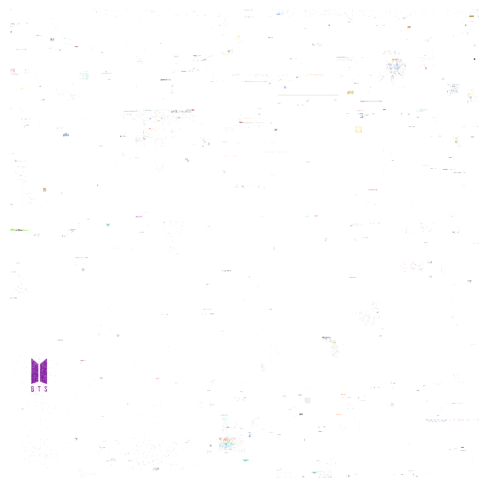

In [ ]:
# First type of bot:
#   A single user placing pixels on even/constant intervals (Bonus points if the same location/color)

CD = 60 * 5 # 60 * 5 minutes
BOT_THRESH = 5
query = f"""
    WITH
        interval_summary AS (
            SELECT
                user_id,
                COUNT(*) AS freq,
                AVG(time_since_last_placed) AS avg_interval,
                STDDEV(time_since_last_placed) AS stdev_interval,
                MIN(time_since_last_placed) AS min_interval,
                MAX(time_since_last_placed) AS max_interval
            FROM
                user_intervals
            WHERE
                time_since_last_placed IS NOT NULL
            GROUP BY
                user_id
            HAVING
                COUNT(*) > 10 AND STDDEV(time_since_last_placed) < 2
            ORDER BY
                STDDEV(time_since_last_placed) ASC
        ),
        sus_repeats AS (
            SELECT
                user_id,
                pixel_color,
                x1, y1,
                COUNT(*) AS repeats
            FROM
                '{PARQUET_PATH}'
            GROUP BY
                user_id, pixel_color, x1, y1
            HAVING
                COUNT(*) > {BOT_THRESH}
        ),
        sus_users AS (
            SELECT
                sr.user_id
            FROM
                sus_repeats AS sr
            JOIN
                interval_summary AS isum ON
                    sr.user_id = isum.user_id
        )
    SELECT
        isum.user_id,
        EPOCH(timestamp) AS timestamp_epoch,
        x1, y1, y1, y2,
        pixel_color
    FROM
        interval_summary AS isum
    JOIN
        '{PARQUET_PATH}' AS pq ON
            isum.user_id = pq.user_id
    ORDER BY
        timestamp ASC
"""

df = duckdb.query(query).df()
xmin, xmax = max(0, df['x1'].min() - 100), df['x1'].max()
ymin, ymax = max(0, df['y1'].min() - 100), df['y1'].max()

createGif(xmin, xmax, ymin, ymax, df, fps=60)
# createCoordGif((xmax-xmin)//2, (ymax-ymin)//2, fps=30, dt=500, bins=1_000)

In [18]:
df

,user_id,timestamp_epoch,x1,y1,x2,y2,pixel_color,rgb,frame
0,1094442,1.648937e+09,1153,302,<NA>,<NA>,#000000,"(0.0, 0.0, 0.0)",16489373.0
1,1094442,1.648938e+09,1162,303,<NA>,<NA>,#FFA800,"(1.0, 0.6588235294117647, 0.0)",16489377.0
2,1094442,1.648938e+09,1164,303,<NA>,<NA>,#FFA800,"(1.0, 0.6588235294117647, 0.0)",16489380.0
3,1094442,1.648938e+09,1150,303,<NA>,<NA>,#000000,"(0.0, 0.0, 0.0)",16489384.0
4,1094442,1.648939e+09,1169,301,<NA>,<NA>,#FFA800,"(1.0, 0.6588235294117647, 0.0)",16489387.0
...,...,...,...,...,...,...,...,...,...
711,9154697,1.649112e+09,1636,646,<NA>,<NA>,#BE0039,"(0.7450980392156863, 0.0, 0.2235294117647059)",16491120.0
712,5984078,1.649112e+09,1584,1395,<NA>,<NA>,#000000,"(0.0, 0.0, 0.0)",16491121.0
713,9154697,1.649112e+09,1637,646,<NA>,<NA>,#BE0039,"(0.7450980392156863, 0.0, 0.2235294117647059)",16491123.0
714,9154697,1.649112e+09,1637,646,<NA>,<NA>,#BE0039,"(0.7450980392156863, 0.0, 0.2235294117647059)",16491123.0


In [ ]:
# Let's see what someone's placements from this list looks like

query = f"""
    SELECT
        user_id,
        EPOCH(timestamp) AS timestamp_epoch,
        x1, y1, x2, y2,
        pixel_color
    FROM
        '{PARQUET_PATH}'
    WHERE
        user_id = 7644988 
"""

df = duckdb.query(query).df()
xmin, xmax = df['x1'].min() - 50, df['x1'].max() + 50
ymin, ymax = df['y1'].min() - 50, df['y1'].max() + 50
createGif(xmin, xmax, ymin, ymax, df, file=f"bot_test_0.gif", fps=30, dt=200)

## Cheaters

These are users who took advantage of r/place updates happening asycronously and placed pixels rapidly without invoking their cooldown timer.

In [170]:
CD = 60 * 5 # Minimum cooldown timer (I think)

query = f"""
    SELECT
        user_id,
        COUNT(*) AS freq
    FROM
        '{PARQUET_PATH}'
    WHERE
        time_since_last_placed < {CD}
    GROUP BY
        user_id
    ORDER BY
        freq DESC
"""
duckdb.query(query).df()

,user_id,freq
0,2880275,67
1,4052128,48
2,5456313,46
3,1884387,33
4,6913737,27
...,...,...
9052,5006279,1
9053,5043725,1
9054,6378752,1
9055,6501217,1


,timestamp,user_id,pixel_color,x1,y1,x2,y2,time_since_last_placed
0,2022-04-01 14:15:05.902,1884387,#000000,860,189,<NA>,<NA>,NaN
1,2022-04-01 14:24:39.439,1884387,#000000,864,190,<NA>,<NA>,573.537
2,2022-04-01 14:30:37.466,1884387,#000000,867,190,<NA>,<NA>,358.027
3,2022-04-01 14:38:32.448,1884387,#FFD635,865,177,<NA>,<NA>,474.982
4,2022-04-01 14:59:40.252,1884387,#FF4500,770,40,<NA>,<NA>,1267.804
...,...,...,...,...,...,...,...,...
359,2022-04-04 21:43:23.242,1884387,#D4D7D9,613,685,<NA>,<NA>,0.005
360,2022-04-04 21:43:23.249,1884387,#00A368,1229,154,<NA>,<NA>,0.007
361,2022-04-04 21:48:35.972,1884387,#3690EA,980,452,<NA>,<NA>,312.723
362,2022-04-04 21:53:45.219,1884387,#000000,857,150,<NA>,<NA>,309.247


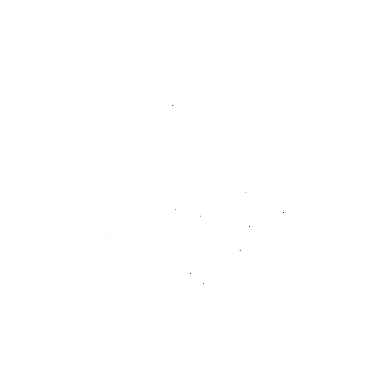

In [ ]:
# createUserGif(1884387, fps=2, dt=500, dr=20)
createCoordGif(630, 660, fps=30, dt=50, dr=50)

duckdb.query(f"SELECT * FROM '{PARQUET_PATH}' WHERE user_id = 1884387").df()

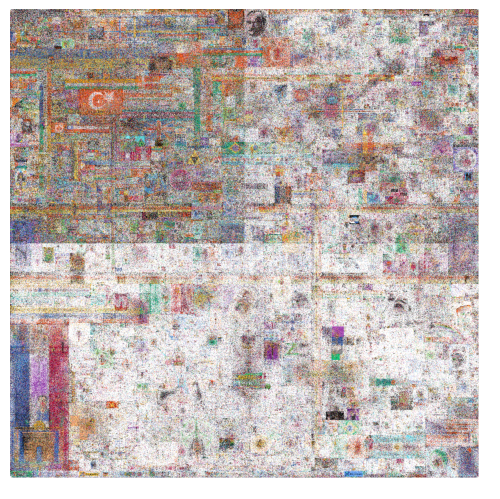

In [ ]:
# Let's look at every user's first time placement

query = f"""
    WITH 
        userOcc AS (
            SELECT
                *,
                ROW_NUMBER() OVER (PARTITION BY user_id ORDER BY timestamp ASC) AS rownum
            FROM
                '{PARQUET_PATH}'
        )
    SELECT
        user_id,
        EPOCH(timestamp) AS timestamp_epoch,
        pixel_color,
        x1, y1, x2, y2
    FROM
        userOcc
    WHERE
        rownum = 1
"""

df = duckdb.query(query).df()
xmin, xmax = 0, df['x1'].max()
ymin, ymax = 0, df['y1'].max()

createGif(xmin, xmax, ymin, ymax, df, bins=1_000, file="first_user_occ_2.gif", fps=30)